# Point 1

In [1]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


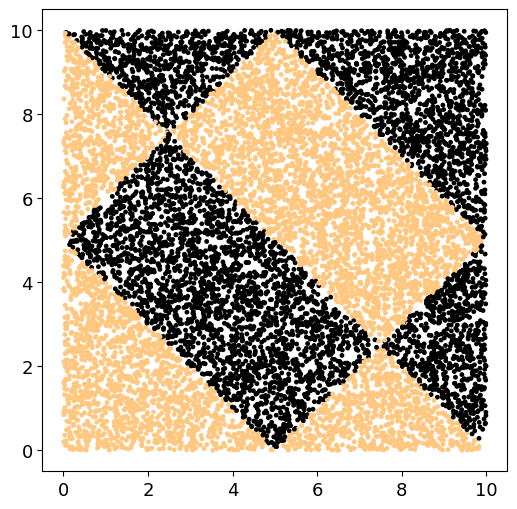

In [2]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

In [3]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [4]:
from keras.optimizers import Adam, RMSprop, SGD

# Parametri per la Grid Search
learning_rates = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
activations = ['sigmoid', 'relu', 'elu']
dropouts = [0.0, 0.1, 0.2]
optim_names = ['adam', 'rmsprop', 'nesterov']
nepoch = 200

learning_rates_idx = 2
dropouts_idx = 1
activations_idx = 2
optim_names_idx = 0

# Helper per associare nome ottimizzatore, LR -> Oggetto Optimizer
def get_optimizer(opt_name, lr):
    if opt_name == 'adam':
        return keras.optimizers.Adam(learning_rate=lr)
    if opt_name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=lr)
    if opt_name == 'nesterov':
        return keras.optimizers.nesterov(learning_rate=lr)


In [5]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

model = Sequential()
model.add(Dense(L,input_shape=(L,),activation=activations[activations_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(20,activation=activations[activations_idx]))
model.add(Dropout(dropouts[dropouts_idx]))
model.add(Dense(1,activation='sigmoid'))

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
model.compile(
    optimizer=get_optimizer(optim_names[optim_names_idx], lr=learning_rates[learning_rates_idx]),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'],
)

In [7]:
fit = model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
168/168 - 2s - 14ms/step - accuracy: 0.5177 - loss: 0.7070 - val_accuracy: 0.5144 - val_loss: 0.6897
Epoch 2/200
168/168 - 0s - 2ms/step - accuracy: 0.5245 - loss: 0.7017 - val_accuracy: 0.5200 - val_loss: 0.6863
Epoch 3/200
168/168 - 0s - 3ms/step - accuracy: 0.5282 - loss: 0.6965 - val_accuracy: 0.5300 - val_loss: 0.6842
Epoch 4/200
168/168 - 0s - 2ms/step - accuracy: 0.5323 - loss: 0.6917 - val_accuracy: 0.5367 - val_loss: 0.6829
Epoch 5/200
168/168 - 0s - 2ms/step - accuracy: 0.5348 - loss: 0.6911 - val_accuracy: 0.5400 - val_loss: 0.6820
Epoch 6/200
168/168 - 0s - 2ms/step - accuracy: 0.5371 - loss: 0.6888 - val_accuracy: 0.5378 - val_loss: 0.6813
Epoch 7/200
168/168 - 0s - 2ms/step - accuracy: 0.5325 - loss: 0.6917 - val_accuracy: 0.5372 - val_loss: 0.6805
Epoch 8/200
168/168 - 0s - 2ms/step - accuracy: 0.5349 - loss: 0.6880 - val_accuracy: 0.5350 - val_loss: 0.6799
Epoch 9/200
168/168 - 0s - 2ms/step - accuracy: 0.5331 - loss: 0.6877 - val_accuracy: 0.5344 - val_loss

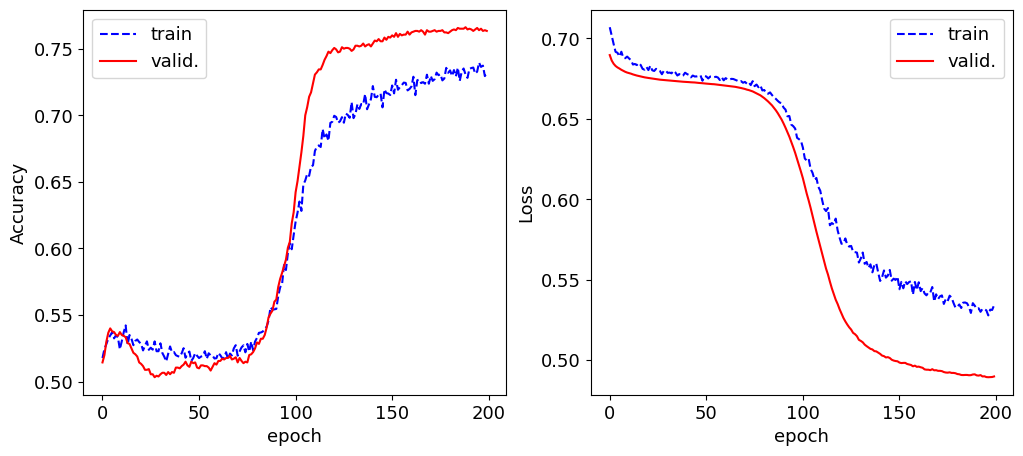

In [8]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4946
Final test accuracy: 0.7550


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


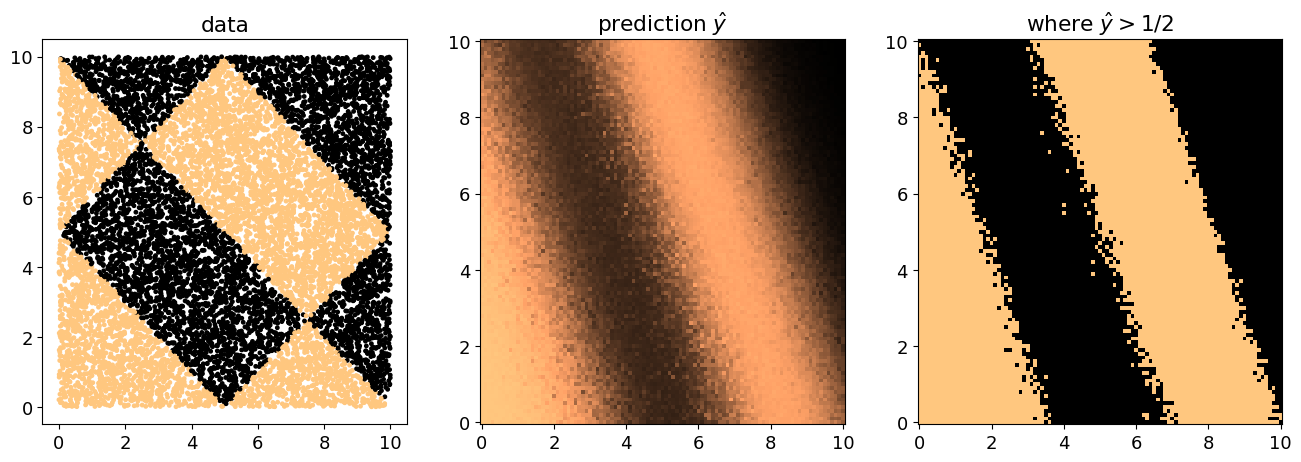

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [10]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

# DNN Training Results Analysis

This notebook presents the comprehensive analysis of the results obtained from training various deep neural network configurations. The main focus is evaluating the impact of hyperparameters (Learning Rate, Activation Function, Dropout, and Optimizer) on the final model performance, measured primarily through `Validation Accuracy`.

## 1. Performance Distribution by Hyperparameter
![Boxplots](plots/1_hyperparams_boxplots.png)

### Analysis of Systematic Behaviors and Outliers:
The boxplot chart offers an immediate and comprehensive view of the marginal effects of each hyperparameter:

- **Activation Function (Systematic Degradation Behavior):** The clearest result of the entire study is evident looking at the top-right panel. It denotes **a systematic behavior where the `sigmoid` function provides extremely poor and unreliable results** compared to modern counterparts. This function typically suffers from the *vanishing gradient* problem, which prevents the network from learning effectively, leading to very low medians and a high variance of weak results (many models remain confined to an accuracy just above random chance). Conversely, **`relu` and `elu` prove to be excellent and systematically winning choices**, exhibiting not only high medians but also a dispersion cloud concentrated in higher values.
- **Learning Rate:** The distributions as a function of LR show the typical "skewed bell" shape. Intermediate values ($10^{-2}$) host almost all the top-performing models. Values that are too low ($10^{-5}$, $10^{-4}$) often struggle to converge (lower median and efficiency with many downward outliers), while values like $10^{-3}$, $10^{-1}$ present numerous **outlier behaviors** in the form of steep drops in performance, caused by unstable gradients or divergent logic.
- **Dropout:** Dropout impacts the global distributions less drastically in this restricted search space. Anyway, slightly better results are seen for dropouts lower than 0.2.
- **Optimizer:** Among the optimizers, slight differences in median value are seen, but all contain very low and very high outliers, often corresponding to malicious configurations (e.g., combined with sigmoid or wrong LRs).

## 2. Learning Rate Sensitivity with respect to the Optimizer
![Val Acc per Optimizer](plots/2_val_acc_by_lr_optimizer.png)

### Motivation of Choices (Optimizer):
This interaction plot highlights the dynamic relationship between optimizer and LR:
- Methods like `Adam` and `RMSprop` tend to have higher accuracy for LRs in the range [$10^{-3}$; $10^{-2}$), while `nesterov` performs well even for higher LRs ($[10^{-2}; 0.5]$).
- **Outliers and Numerical Instability:** For high LRs, methods like `Adam` and `RMSprop` plummet vertiginously, whereas `nesterov` performs better, showing on average faster and computationally smoother convergence. `nesterov` shows an extremely higher variability as both a merit and a flaw: if on the one hand it is much more dependent on other parameters (high variability), on the other it shows many more outliers that allow obtaining high accuracy even with LRs for which other models averagely seem to excel.
Either way, **the optimal choice averagely suggests adopting an LR around $10^{-2}$**.

## 3. Learning Rate Sensitivity with respect to Activation
![Val Acc per Activation](plots/3_val_acc_by_lr_activation.png)

### Reconfirmation of Extreme Systematic Behaviors:
The graph re-proposes what was observed previously, conferring it parametric robustness:
- The trace corresponding to the **`sigmoid` is almost constantly the worst** at every investigated learning rate value. It barely reaches or touches the marginal performance of the other activations in isolated spots where `relu` and `elu` are already chronically collapsing due to instability at high regimes (LR = $10^{-1}$).
- The scalar convergence profiles of **`relu` and `elu` describe a clear parabolic shape in log-scale**, dictating as an empirical gold standard their rapid implementation for the vast majority of feed-forward network tasks. Maintaining the `relu`/`elu` activation is a fundamental prerequisite in this project to raise the maximum accuracy benchmark.

## 4. Top 5 Configurations Analysis
![Top 5 Models](plots/4_top_5_models.png)

### Motivation of the Excellent Winners:
The close comparison among the absolute top 5 in Validation Accuracy with the hold-out metric (Test Accuracy):
- **Winning choices:** As expected, no best-in-class run uses sigmoid or LR outside of $[10^{-3};10^{-1}]$. All align with absolute dominance on `elu` or `relu` activations paired with perfectly centered LRs.
- **Robust Generalization (Absence of Overfitting):** The elite configurations record an insignificant gap, in some neighbors almost invisible, between Validation and Test Accuracy. On average, as seen, the applied topology optimally regularizes the network; nevertheless, exactly 3 models among the top 5 have `nesterov` as the optimizer: these results configure themselves, as seen, as *statistical outliers*.

## 5. Local Sensitivity Analysis (The Top 5 Models)
In the subsections below, we analyze how accuracies vary by shifting, for each of the top 5 models (keeping all other factors constant), one unknown parameter at a time (starting and comparing from the optimal setup indicated by a red star on the graph).

### Top 1 Model Analysis
![Top 1 Analysis](plots/5_top1_model_analysis.png)

### Top 2 Model Analysis
![Top 2 Analysis](plots/5_top2_model_analysis.png)

### Top 3 Model Analysis
![Top 3 Analysis](plots/5_top3_model_analysis.png)

### Top 4 Model Analysis
![Top 4 Analysis](plots/5_top4_model_analysis.png)

### Top 5 Model Analysis
![Top 5 Analysis](plots/5_top5_model_analysis.png)

### Neighborhood Explorations (Robustness and Drops):
- **Activation function stability:** The `sigmoid` is confirmed again as the worst *activation function*. The sigmoid is the latent variable of undeniable deterioration of the observed performances.
- **Learning rate sensitivity:** In many of such slices (section of the variation gradient at a single degree of freedom), the impetuous variances of the chosen `optimizer` or `learning_rate` generate precipitous drops in validation accuracy.
- The highlighted key lesson reiterates that the empirical success of a deep network lies in a narrow *sweet-spot* or unified domain: foolishly perturbing a calibrated synergy of a Top Model (perhaps changing the optimizer in favor of the insidious and primitive SGD on that range) will cause a drastic decrease. The best exposed choices demonstrate the inviolability of the calibrated trade-off between a non-blocking function like **relu/elu** combined with an optimizer like **Adam/RMSprop** with an LR in the range [$10^{-3}$; $10^{-2}$), while (activation function being equal) `nesterov` performs well even for higher LRs ($[10^{-2}; 0.5]$) but the latter in a very unstable way giving good results only as an outlier.

# Exercise 2

# Point 2.a

In [11]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

In [12]:
%run useful.py

# training/validation fractions
perc_train = np.arange(0.1, 1, 0.1)
perc_valid = 1 - perc_train

print(perc_valid)

[0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]


(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: [ 1200  2400  3600  4800  6000  7200  8400  9600 10800]
valid: [10800  9600  8400  7200  6000  4800  3599  2399  1199]


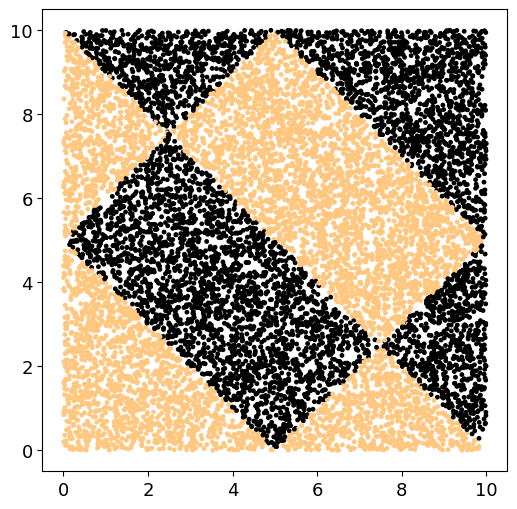

In [13]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = (perc_train * N).astype(int)
N_valid = (perc_valid * N).astype(int)
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}')

plot_data(x,y)

In [14]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

def sets_constructor(N_train, N_valid):

    # split data into train/validation sets and check
    (x_train, y_train) = (x[0:N_train],y[0:N_train])
    (x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
    print("Train:",len(x_train),"\t Validation:",len(x_valid))


    x_train_mean = np.mean(x_train, axis=0)
    x_train_std = np.std(x_train, axis=0)
    #print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

    x_valid_mean = np.mean(x_valid, axis=0)
    x_valid_std = np.std(x_valid, axis=0)
    #print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)


    x_train = Standardize(x_train, x_train_mean, x_train_std)
    x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
    print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

    return x_train, y_train, x_valid, y_valid, x_train_mean, x_train_std

In [15]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)


n_sets = N_train.size

output_file = "results_2a.csv"
results_list = []

for i in range(n_sets):
    
    x_train, y_train, x_valid, y_valid, _, _= sets_constructor(N_train[i], N_valid[i])

    model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'],
                )
    nepoch=200
    
    fit = model.fit(x_train, y_train,
                epochs = nepoch, batch_size = 50,
                validation_data=(x_valid,y_valid),
                verbose=0)
    
    res = {
        '% training data' : perc_train[i],
        '% validation data' : perc_valid[i],
        'val_loss': fit.history['val_loss'][-1], # Ultimo valore di validation
        'val_accuracy': fit.history['val_accuracy'][-1]
    }
    results_list.append(res)
    pd.DataFrame([res]).to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))
    print(f"Completed run {i} of {n_sets-1}")

Train: 1200 	 Validation: 10800
after rescaling (train):
mean value= [-4.95437025e-16 -1.07247544e-15 -3.38895578e-16 -2.44859688e-15
 -7.64666108e-16 -6.57807142e-16 -2.75335310e-16 -2.45729363e-16] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 0 of 8
Train: 2400 	 Validation: 9600
after rescaling (train):
mean value= [ 4.01493653e-15  1.01113562e-15  1.39730820e-15 -2.16091034e-15
 -5.25413046e-15 -4.63351579e-15 -1.15124345e-15 -1.47348569e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 1 of 8
Train: 3600 	 Validation: 8400
after rescaling (train):
mean value= [-1.11083982e-16  3.22359423e-15 -1.77228602e-15 -2.85210127e-15
 -4.40070819e-15 -3.43271707e-15 -2.39968539e-15 -1.40911973e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


...

Completed run 6 of 8
Train: 9600 	 Validation: 2399
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 7 of 8
Train: 10800 	 Validation: 1199
after rescaling (train):
mean value= [ 1.91540199e-15  7.85519797e-15 -4.43082299e-15 -4.90277572e-15
 -4.45316366e-15 -2.19519876e-15  4.39740836e-16 -7.81854005e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 8 of 8


In [16]:
#Retrain the best setup for the plot
x_train, y_train, x_valid, y_valid, x_train_mean, x_train_std = sets_constructor(N_train[5], N_valid[5])

model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
            )
nepoch=200

fit = model.fit(x_train, y_train,
            epochs = nepoch, batch_size = 50,
            validation_data=(x_valid,y_valid),
            verbose=2)

Train: 7200 	 Validation: 4800
after rescaling (train):
mean value= [ 4.97429258e-15  7.58550630e-15 -3.36221791e-15 -1.12749316e-16
 -3.14578610e-15 -2.87425947e-15 -2.72715492e-15 -2.54271912e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]
Epoch 1/200


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 - 1s - 9ms/step - accuracy: 0.5274 - loss: 0.6878 - val_accuracy: 0.5337 - val_loss: 0.6793
Epoch 2/200
144/144 - 1s - 4ms/step - accuracy: 0.5374 - loss: 0.6745 - val_accuracy: 0.5498 - val_loss: 0.6651
Epoch 3/200
144/144 - 1s - 4ms/step - accuracy: 0.5522 - loss: 0.6604 - val_accuracy: 0.5804 - val_loss: 0.6486
Epoch 4/200
144/144 - 1s - 4ms/step - accuracy: 0.5811 - loss: 0.6415 - val_accuracy: 0.5962 - val_loss: 0.6306
Epoch 5/200
144/144 - 1s - 4ms/step - accuracy: 0.6122 - loss: 0.6253 - val_accuracy: 0.6279 - val_loss: 0.6111
Epoch 6/200
144/144 - 1s - 4ms/step - accuracy: 0.6351 - loss: 0.6099 - val_accuracy: 0.6585 - val_loss: 0.5928
Epoch 7/200
144/144 - 1s - 5ms/step - accuracy: 0.6572 - loss: 0.5930 - val_accuracy: 0.6852 - val_loss: 0.5704
Epoch 8/200
144/144 - 1s - 4ms/step - accuracy: 0.6712 - loss: 0.5740 - val_accuracy: 0.6942 - val_loss: 0.5524
Epoch 9/200
144/144 - 1s - 4ms/step - accuracy: 0.6918 - loss: 0.5583 - val_accuracy: 0.7102 - val_loss: 0.5344
Epoc

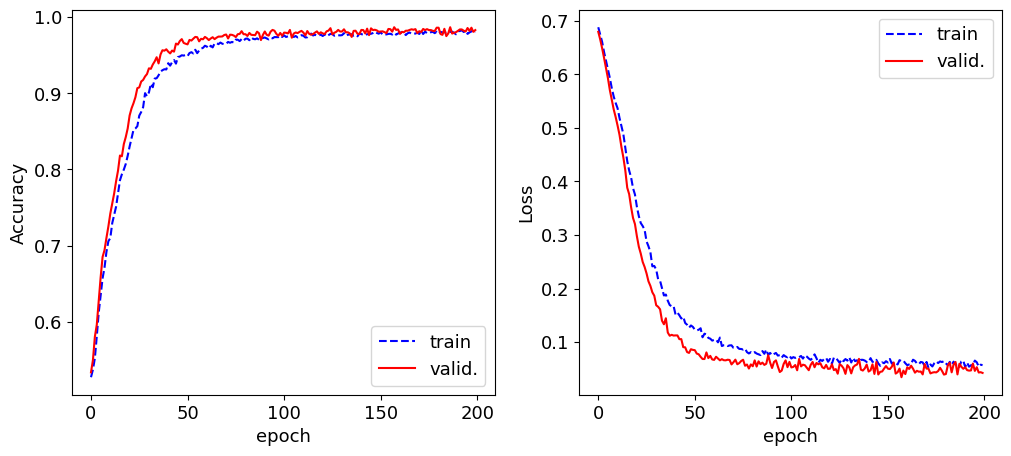

In [17]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


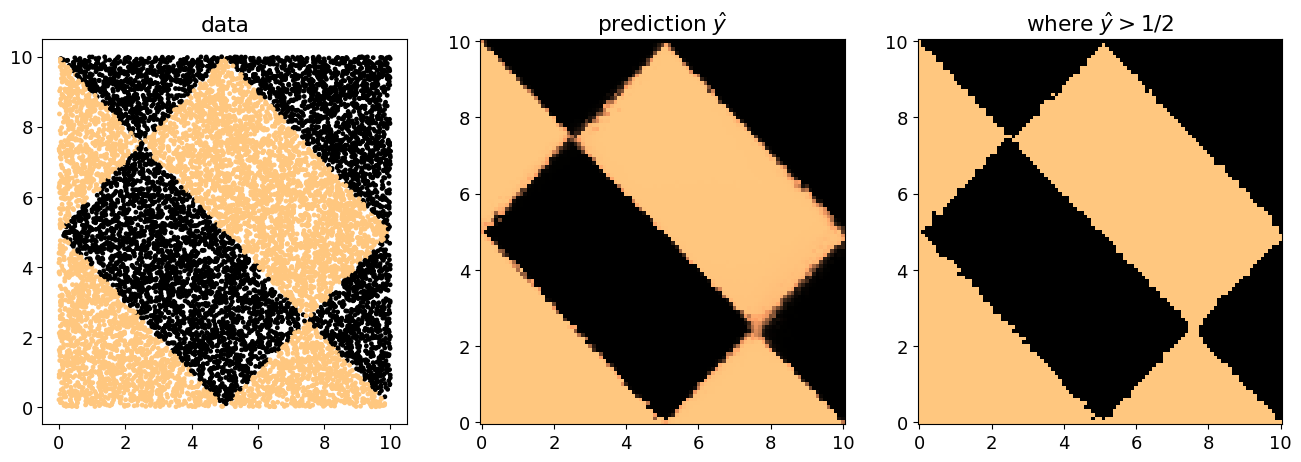

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [18]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

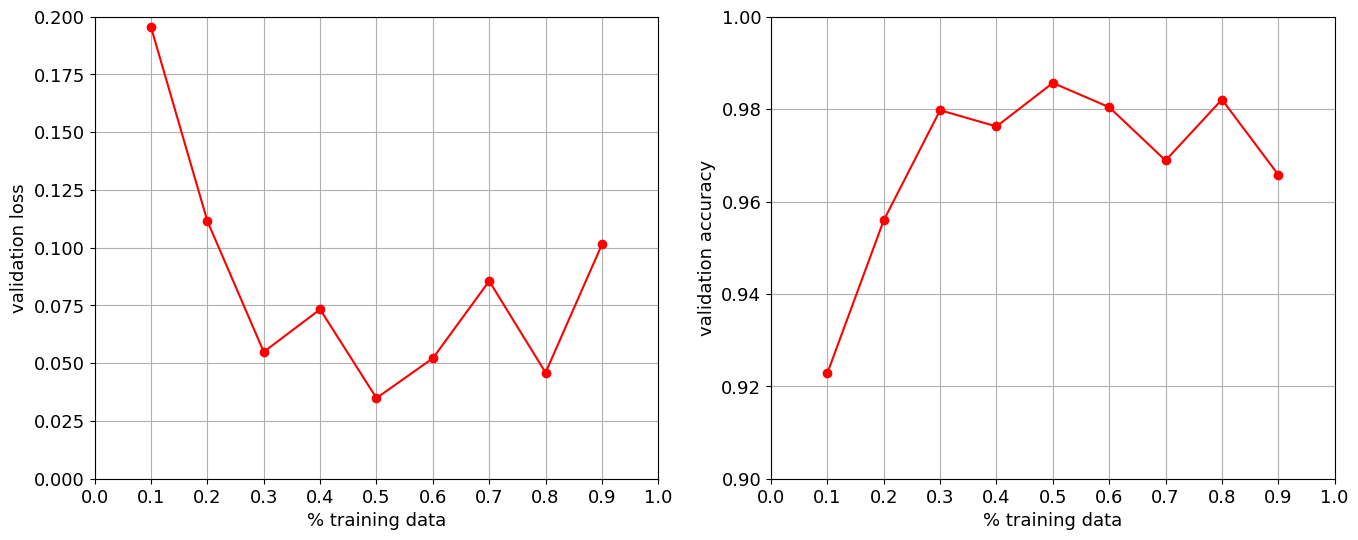

In [19]:
#Plots of accuracy and loss

results = pd.read_csv("results_2a.csv")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
ax[0].plot(results["% training data"], results["val_loss"], marker='o', color='red')
ax[1].plot(results["% training data"], results["val_accuracy"], marker='o', color='red')

ticks = np.arange(0, 1.1, 0.1)

ax[0].set_xlabel("% training data"); ax[0].set_ylabel("validation loss")
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 0.2); ax[0].set_xticks(ticks)
ax[0].grid()

ax[1].set_xlabel("% training data"); ax[1].set_ylabel("validation accuracy")
ax[1].set_xlim(0, 1); ax[1].set_ylim(0.9, 1); ax[1].set_xticks(ticks)
ax[1].grid()

plt.show()

# Point 2.b

In [20]:
# Data loading and splitting
# NOTE: this section is copied from the shared Exercise 1 notebook

TYPE = 3
L = 8
B = 10

x = np.loadtxt(filename("data", L, TYPE), delimiter=' ')
y = np.loadtxt(filename("labels", L, TYPE), delimiter=' ').astype(int)

N = len(x)
perc_train = 0.7
perc_valid = 0.15
N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test  = N - N_train - N_valid

x_train, y_train = x[:N_train], y[:N_train]
x_valid, y_valid = x[N_train:N_train+N_valid], y[N_train:N_train+N_valid]
x_test,  y_test  = x[N_train+N_valid:], y[N_train+N_valid:]

# Standardize using training set statistics
x_train_mean = x_train.mean(axis=0)
x_train_std  = x_train.std(axis=0)

def Standardize(x, m, s):
    return (x - np.tile(m, (len(x), 1))) / np.tile(s, (len(x), 1))

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_train_mean, x_train_std)
x_test  = Standardize(x_test,  x_train_mean, x_train_std)

print(f"N_train: {N_train}, N_valid: {N_valid}, N_test: {N_test}")

N_train: 8400, N_valid: 1800, N_test: 1800


In [21]:
import pandas as pd


# Best params from Point 1 (grid search result)


best_params = {
    'lr': 0.001,
    'activation': 'relu',
    'drop': 0.1,
    'opt_name': 'rmsprop',
    'input_dim': L
}


# Helper: build, train, and evaluate a DNN


def train_and_evaluate(x_tr, y_tr, x_val, y_val, x_te, y_te, params, nepoch=200):
    tf.keras.backend.clear_session()

    optim_map = {
        'adam':    tf.keras.optimizers.Adam,
        'rmsprop': tf.keras.optimizers.RMSprop,
        'sgd':     tf.keras.optimizers.SGD
    }

    L_         = params['input_dim']
    activation = params['activation']
    drop       = params['drop']
    lr         = params['lr']
    opt_name   = params['opt_name']

    model = Sequential([
        Input(shape=(L_,)),
        Dense(L_,  activation=activation),
        Dense(20, activation=activation), Dropout(drop),
        Dense(20, activation=activation), Dropout(drop),
        Dense(20, activation=activation), Dropout(drop),
        Dense(1,  activation='sigmoid')
    ])

    model.compile(
        optimizer=optim_map[opt_name](learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_tr, y_tr,
              epochs=nepoch,
              batch_size=256,
              validation_data=(x_val, y_val),
              verbose=0)

    return model.evaluate(x_te, y_te, verbose=0)[1] #test accuracy
# =============================================================================
# Augmentation
# Generate artificial training samples by adding small random fluctuations,
# then study how test accuracy changes as the augmentation factor grows.
# Validation and test sets are never augmented.
# =============================================================================

N_full = len(x_train)  # original number of training samples

# Augmentation multipliers: 1x = baseline (no augmentation), 2x, 4x, 8x
augmentation_factors = [1, 2, 4, 8]
aug_accuracies = []

# Noise std chosen relative to standardized scale (feature std = 1 after standardization)
noise_level = 0.1


results_aug = []

np.random.seed(42)
for factor in augmentation_factors:
    n_artificial = (factor - 1) * N_full
    if n_artificial == 0:
        x_tr_aug = x_train.copy()
        y_tr_aug = y_train.copy()
    else:
        # Pick random original samples and add small Gaussian noise
        idx = np.random.choice(N_full, n_artificial, replace=True)
        x_artificial = (x_train[idx]
                        + np.random.normal(0, noise_level,
                                           (n_artificial, x_train.shape[1])))
        y_artificial = y_train[idx]
        x_tr_aug = np.vstack([x_train, x_artificial])
        y_tr_aug = np.concatenate([y_train, y_artificial])

    acc = train_and_evaluate(x_tr_aug, y_tr_aug,
                             x_valid, y_valid,
                             x_test,  y_test,
                             best_params)
    aug_accuracies.append(acc)
    results_aug.append({
        'augmentation_factor': factor,
        'n_train':             len(x_tr_aug),
        'noise_level':         noise_level,
        'test_accuracy':       acc
    })
    print(f"Augmentation {factor}x  —  N_train: {len(x_tr_aug):6d},  Test Acc: {acc:.4f}")



2026-03-11 14:37:54.099896: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Augmentation 1x  —  N_train:   8400,  Test Acc: 0.9828
Augmentation 2x  —  N_train:  16800,  Test Acc: 0.9750
Augmentation 4x  —  N_train:  33600,  Test Acc: 0.9783
Augmentation 8x  —  N_train:  67200,  Test Acc: 0.9611


   augmentation_factor  n_train  noise_level  test_accuracy
0                    1     8400          0.1       0.982778
1                    2    16800          0.1       0.975000
2                    4    33600          0.1       0.978333
3                    8    67200          0.1       0.961111


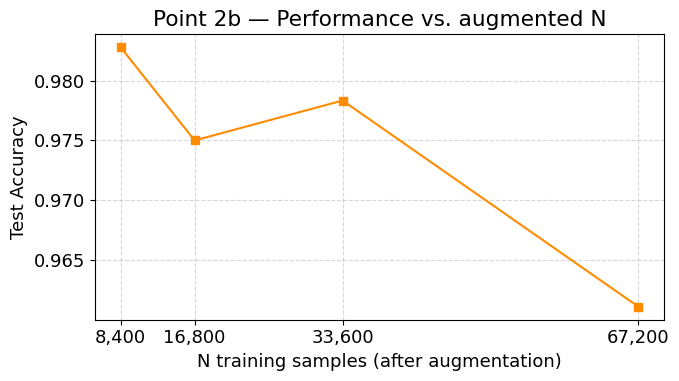

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Save results to CSV
df_aug = pd.DataFrame(results_aug)
df_aug.to_csv('results_augmentation.csv', index=False)
print(df_aug)

# Carica dal CSV (o usa df_aug già esistente)
df_aug = pd.read_csv('results_augmentation.csv')

# Plot usando colonne reali del CSV
plt.figure(figsize=(7, 4))
plt.plot(df_aug['n_train'], df_aug['test_accuracy'], 's-', color='darkorange')
plt.xlabel('N training samples (after augmentation)')
plt.ylabel('Test Accuracy')
plt.title('Point 2b — Performance vs. augmented N')
plt.xticks(df_aug['n_train'], [f'{int(n):,}' for n in df_aug['n_train']])
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('point2b_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()



The training set (N = 8400) was augmented by adding Gaussian noise to randomly selected training samples:
$$x_{\text{aug}} = x_{\text{original}} + \epsilon, \quad \epsilon \sim \mathcal{N}(0,\, \sigma^2), \quad \sigma = 0.1$$
The noise level σ = 0.1 was chosen to be small relative to the standardized feature scale (std = 1), producing realistic perturbations without altering the class label. The validation and test sets were never augmented. Four augmentation factors were tested:

| Factor | N training | Test Accuracy |
|--------|------------|---------------|
| 1× (baseline) | 8 400  | 0.9828 |
| 2×           | 16 800 | 0.9750 |
| 4×           | 33 600 | 0.9783 |
| 8×           | 67 200 | 0.9611 |

The results show no consistent trend: accuracy fluctuates within ~0.022 across all factors, which falls within the stochastic variability of DNN training. No clear improvement or degradation can be attributed to augmentation.

These results can be explained by the strong baseline performance (~98% test accuracy) with minimal overfitting, leaving little room for noise-based augmentation to provide gains. The observed fluctuations likely stem from random weight initialization and training stochasticity rather than augmentation effects.